 Assignment - Mall Customer Segmentation
1. Download the Mall Customer Segmentation dataset from kaggle (Search 'Mall Cusotmer Segmentation Data - Vijay).
2. Run K-means for K = 2 upto 10 and plot the elbow curve.
3. Choose the best K and profile each customer segment.
4. Give each cluster a marketing label (eg 'Budget shoppers', 'VIPS', etc)
5. __CHALLENGE__: Run hierachical clustering on the same data and compare the segments.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
print(df.shape)


(200, 5)


In [12]:
X=df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.cluster import KMeans


inertia=[]

for k in range(2, 11):
    km= KMeans(n_clusters=k,random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

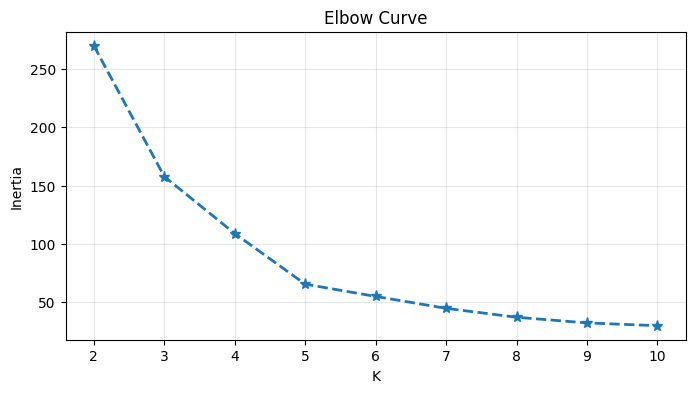

In [17]:
#PLOT ELBOW CURVE 

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertia, '*--', linewidth=2, markersize=8)

plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.show()

In [23]:
km=5
km= KMeans(n_clusters=k,random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)
df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,4,4
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1
196,197,Female,45,126,28,3,3
197,198,Male,32,126,74,1,1
198,199,Male,32,137,18,3,3


In [25]:
profile= df.groupby('Cluster').agg({
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean',
    'Age':'mean',
    'CustomerID':'count'
}).rename(columns={'cluster':'count'}).round(0)

print(profile)

         Annual Income (k$)  Spending Score (1-100)   Age  CustomerID
Cluster                                                              
0                      55.0                    50.0  43.0          81
1                      87.0                    82.0  33.0          39
2                      26.0                    79.0  25.0          22
3                      88.0                    17.0  41.0          35
4                      26.0                    21.0  45.0          23


In [30]:
# PLot the clusters


labels = {
    0: 'Budget Shoppers',
    1: 'Impulsive Spenders',
    2: 'Occasional Spenders',
    3: 'Wealthy',
    4: 'VIPs'
}

df['Marketing Label'] = df['Cluster'].map(labels)

print(df['Marketing Label'].value_counts())

Marketing Label
Budget Shoppers        81
Impulsive Spenders     39
Wealthy                35
VIPs                   23
Occasional Spenders    22
Name: count, dtype: int64


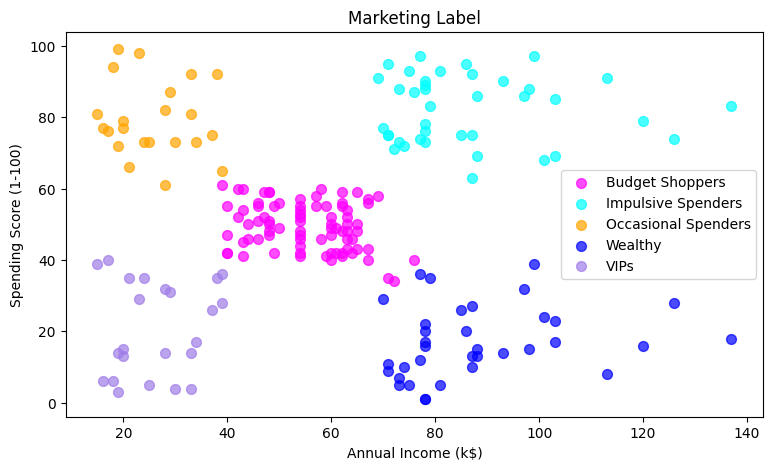

In [36]:
#Visualizing clusters

colours= ['#FF00FF','#00FFFF','#FFA500','#0000FF','#a07de8']
labels = [ 'Budget Shoppers','Impulsive Spenders','Occasional Spenders','Wealthy','VIPs']

plt.figure(figsize=(9, 5))
for c in range(5):
    mask = df['cluster'] ==c

    plt.scatter(
        df[mask]['Annual Income (k$)'],
        df[mask]['Spending Score (1-100)'],
        c=colours[c],label= labels[c], alpha=0.7, s=50
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Marketing Label')
plt.legend()
plt.show()

In [37]:
#Heirachical Clustering

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [41]:
Z=df

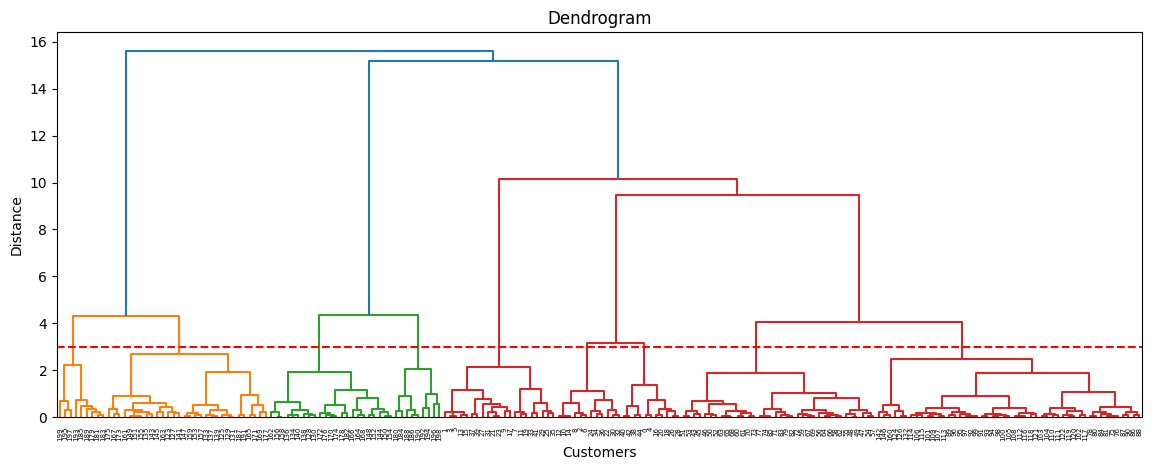

In [44]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='level')
plt.axhline(y = 3, color='red', linestyle = '--', linewidth = 1.5)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()


In [ ]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

In [47]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Cluster,Segment,Marketing Label,hc_cluster
0,1,Male,19,15,39,4,4,VIPs,VIPs,0
1,2,Male,21,15,81,2,2,Standard Customers,Occasional Spenders,3
2,3,Female,20,16,6,4,4,VIPs,VIPs,0
3,4,Female,23,16,77,2,2,Standard Customers,Occasional Spenders,3
4,5,Female,31,17,40,4,4,VIPs,VIPs,0
...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1,Impulsive Spenders,Impulsive Spenders,1
196,197,Female,45,126,28,3,3,Wealthy,Wealthy,2
197,198,Male,32,126,74,1,1,Impulsive Spenders,Impulsive Spenders,1
198,199,Male,32,137,18,3,3,Wealthy,Wealthy,2


In [59]:
# Compare K-means vs hierachical clustering
print("K-means cluster profiles")
print(df.groupby('cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean().round(0))
                             

K-means cluster profiles
         Annual Income (k$)  Spending Score (1-100)
cluster                                            
0                      55.0                    50.0
1                      87.0                    82.0
2                      26.0                    79.0
3                      88.0                    17.0
4                      26.0                    21.0


In [52]:
print("Hierarchical cluster profiles")
print(df.groupby('hc_cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(0))

Hierarchical cluster profiles
            Annual Income (k$)  Spending Score (1-100)
hc_cluster                                            
0                         50.0                    43.0
1                         87.0                    82.0
2                         89.0                    16.0
3                         25.0                    80.0


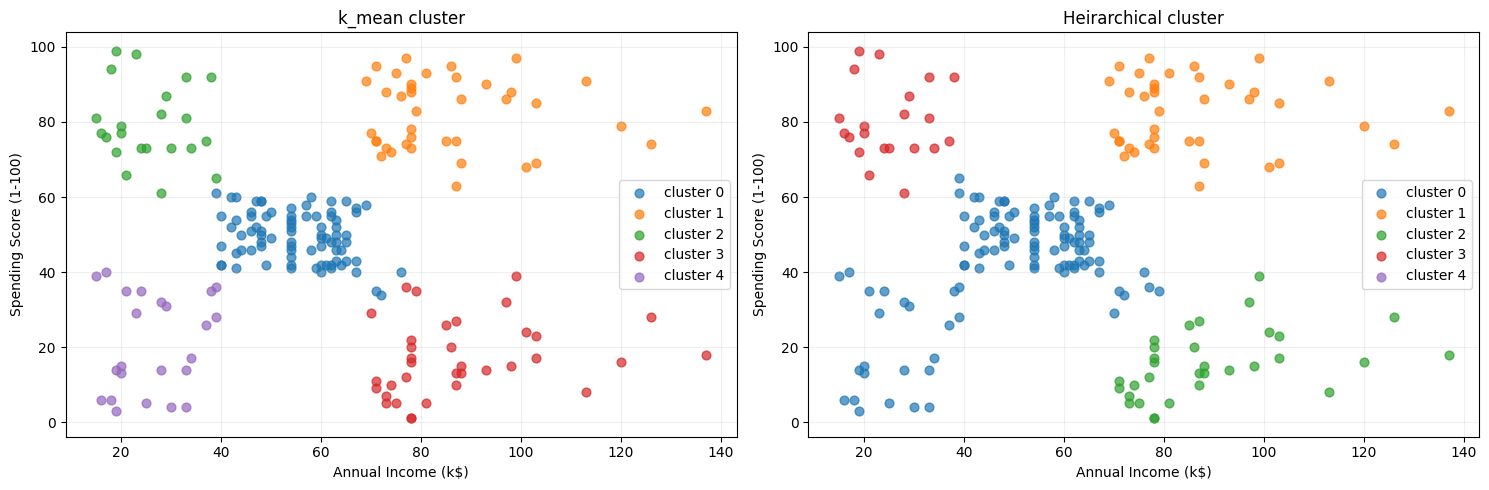

In [63]:
#scatter plot comparing both clusters

fig,ax=plt.subplots(1,2,figsize=(15,5))

for ax,col,titleX in  zip(
    ax,
    ['cluster','hc_cluster'],
    ['k_mean cluster','Heirarchical cluster']

):
    for c in range(5):
        mask=df[col]==c
        ax.scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],
                   alpha = 0.7, s=40, label =f'cluster {c}')
        ax.set_xlabel('Annual Income (k$)')
        ax.set_ylabel('Spending Score (1-100)')
        ax.set_title(titleX)
        ax.legend()
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
        


    
